# Model Fitting

In [1]:
# Data librarie
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedGroupKFold
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPRegressor
from xgboost import XGBClassifier


import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.metrics import (precision_score, recall_score, balanced_accuracy_score, 
                             f1_score, average_precision_score, precision_recall_curve,
                             roc_auc_score, classification_report, ConfusionMatrixDisplay)

## Load Dataset

In [2]:
metadata = pd.read_pickle("metadata.pkl")
metadata_tfidf_df = pd.read_pickle("metadata_tfidf.pkl")
metadata_llm_embedding_df = pd.read_pickle("metadata_llm_embedding.pkl")
metadata_embedding_semantic_df = pd.read_pickle("metadata_embedding_semantic.pkl")

In [3]:
datasets = {
    "metadata": metadata,
    "metadata_tfidf": metadata_tfidf_df,
    "metadata_llm_embedding_df": metadata_llm_embedding_df,
    "metadata_embedding_semantic_df": metadata_embedding_semantic_df
}

## Train/Test split

In [4]:
# Prepare the base dataset for generating employee-level train/test splits
# Use userID as the grouping variable to ensure that the same employee does not appear in both training and testing sets
base_df = metadata.copy()

X_base = base_df.drop(columns=["user", "week_start", "malicious"])
y_base = base_df["malicious"]

groups = base_df["user"]

# create stratified group cross-validation folds to preserve class distribution while keeping all records from the same employee
# within a single split
cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

fold_indices = []

# generate and store train/test indices so that identical employee splits can be applied across all feature datasets
for fold, (train_idx, test_idx) in enumerate(cv.split(X_base, y_base, groups),start=1):

    fold_indices.append(
        {
            "fold": fold,
            "train_idx": train_idx,
            "test_idx": test_idx
        }
    )

# Display the class distribution in each test fold
for fold, (_, test_idx) in enumerate(cv.split(X_base, y_base, groups=base_df["user"]),start=1):
    
    y_test = y_base.iloc[test_idx]

    print(
        f"Fold {fold}: "
        f"Benign = {(y_test == 0).sum()}, "
        f"Malicious = {(y_test == 1).sum()}"
    )

Fold 1: Benign = 94490, Malicious = 4
Fold 2: Benign = 94489, Malicious = 10
Fold 3: Benign = 94494, Malicious = 4


In [5]:
# store train/test splits for each datasets
all_splits = {}

# apply the same employee-level train/test splits to each feature dataset
for dataset_name, df in datasets.items():

    dataset_splits = []

    # apply the pre-generated fold index to the current dataset
    for fold_info in fold_indices:
        train_idx = fold_info["train_idx"]
        test_idx = fold_info["test_idx"]

        # separate features and target variables
        X = df.drop(columns=["malicious", "user", "week_start"])
        y = df["malicious"]

        # store the training and testing data for the current fold
        split = {
            "fold": fold_info["fold"],
            "X_train": X.iloc[train_idx],
            "X_test": X.iloc[test_idx],
            "y_train": y.iloc[train_idx],
            "y_test": y.iloc[test_idx]
        }

        dataset_splits.append(split)

    # store all fold for the current feature dataset
    all_splits[dataset_name] = dataset_splits

## Model Fitting

In [6]:
# store results
per_fold_results = []

agg_y_test = defaultdict(list)
agg_y_prob = defaultdict(list)
agg_y_pred = defaultdict(list)

### Logistic Regression

In [7]:
for dataset_name, folds in all_splits.items():

    for fold_data in folds:

        fold = fold_data["fold"]

        X_train = fold_data["X_train"]
        X_test = fold_data["X_test"]
        y_train = fold_data["y_train"]
        y_test = fold_data["y_test"]

        # feature scaling
        scaler = RobustScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42
        )

        model.fit(X_train_scaled,y_train)

        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        # evaluation
        precision = precision_score(y_test,y_pred,zero_division=0)
        recall = recall_score(y_test,y_pred,zero_division=0)
        f1 = f1_score(y_test,y_pred,zero_division=0)
        pr_auc = average_precision_score(y_test,y_prob)
        roc_auc = roc_auc_score(y_test,y_prob)
  
        # store fold results
        per_fold_results.append({
            "dataset": dataset_name,
            "fold": fold,
            "model": "Logistic Regression",
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "pr_auc": pr_auc,
            "roc_auc": roc_auc
        })

        result = (dataset_name,"Logistic Regression")
        agg_y_test[result].append(y_test)
        agg_y_prob[result].append(y_prob)
        agg_y_pred[result].append(y_pred)

### Isolation Forest

In [8]:
for dataset_name, folds in all_splits.items():

    for fold_data in folds:

        fold = fold_data["fold"]

        X_train = fold_data["X_train"]
        X_test = fold_data["X_test"]
        y_test = fold_data["y_test"]

        model = IsolationForest(
            n_estimators=500,
            contamination=0.001,
            max_features=1.0,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train)

        if_prediction = model.predict(X_test)
        y_pred = (if_prediction == -1).astype(int)
        y_prob = -model.score_samples(X_test)

        # evaluation
        precision = precision_score(y_test,y_pred,zero_division=0)
        recall = recall_score(y_test,y_pred,zero_division=0)
        f1 = f1_score(y_test,y_pred,zero_division=0)
        pr_auc = average_precision_score(y_test,y_prob)
        roc_auc = roc_auc_score(y_test,y_prob)


        # Store fold results
        per_fold_results.append({
            "dataset": dataset_name,
            "fold": fold,
            "model": "Isolation Forest",
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "pr_auc": pr_auc,
            "roc_auc": roc_auc
        })

        result = (dataset_name,"Isolation Forest")
        agg_y_test[result].append(y_test)
        agg_y_prob[result].append(y_prob)
        agg_y_pred[result].append(y_pred)

### Deep Autoencoder

In [9]:
for dataset_name, folds in all_splits.items():

    for fold_data in folds:

        fold = fold_data["fold"]

        X_train = fold_data["X_train"]
        X_test = fold_data["X_test"]
        y_train = fold_data["y_train"]
        y_test = fold_data["y_test"]

        # feature scaling
        scaler = RobustScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
  
        # keep benign training samples only
        X_train_benign = X_train_scaled[y_train == 0]

        model = MLPRegressor(
            hidden_layer_sizes=(128, 64, 32, 64, 128),
            activation="relu",
            solver="adam",
            learning_rate_init=0.002,
            batch_size=512,
            max_iter=150,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            tol=1e-3,
            random_state=42
        )

        model.fit(X_train_benign,X_train_benign)
        
        # train's reconstruction error
        X_train_reconstructed = model.predict(X_train_benign)
        train_reconstruction_error = np.mean(
            np.square(X_train_benign-X_train_reconstructed
            ),axis=1
        )

        # anomaly threshold
        threshold = np.percentile(train_reconstruction_error,99.9)

        # test's reconstruction error
        X_test_reconstructed = model.predict(X_test_scaled)
        reconstruction_error = np.mean(
            np.square(X_test_scaled-X_test_reconstructed
            ),axis=1
        )

        # predict anomalies
        y_prob = reconstruction_error
        y_pred = (reconstruction_error >= threshold).astype(int)

        # evaluation
        precision = precision_score(y_test,y_pred,zero_division=0)
        recall = recall_score(y_test,y_pred,zero_division=0)
        f1 = f1_score(y_test,y_pred,zero_division=0)
        pr_auc = average_precision_score(y_test,y_prob)
        roc_auc = roc_auc_score(y_test,y_prob)

        # Store fold results
        per_fold_results.append({
            "dataset": dataset_name,
            "fold": fold,
            "model": "Deep Autoencoder",
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "pr_auc": pr_auc,
            "roc_auc": roc_auc
        })

        result = (dataset_name,"Deep Autoencoder")
        agg_y_test[result].append(y_test)
        agg_y_prob[result].append(y_prob)
        agg_y_pred[result].append(y_pred)


## Results

In [10]:
# convert fold results
per_fold_results_df = pd.DataFrame(per_fold_results)

# aggregated evaluation
aggregated_results = []

for (dataset_name, model_name), y_test_list in agg_y_test.items():

    y_test_all = np.concatenate(y_test_list)
    y_prob_all = np.concatenate(agg_y_prob[(dataset_name, model_name)])
    y_pred_all = np.concatenate(agg_y_pred[(dataset_name, model_name)])

    precision = precision_score(y_test_all,y_pred_all,zero_division=0)
    recall = recall_score(y_test_all,y_pred_all,zero_division=0)
    f1 = f1_score(y_test_all,y_pred_all,zero_division=0)
    pr_auc = average_precision_score(y_test_all,y_prob_all)
    roc_auc = roc_auc_score(y_test_all,y_prob_all)

    aggregated_results.append({
        "dataset": dataset_name,
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc
    })

# Final results
aggregated_results_df = pd.DataFrame(aggregated_results)
aggregated_results_df

,dataset,model,precision,recall,f1,pr_auc,roc_auc
0,metadata,Logistic Regression,0.0,0.0,0.0,0.000107,0.685978
1,metadata_tfidf,Logistic Regression,0.0,0.0,0.0,0.000122,0.658522
2,metadata_llm_embedding_df,Logistic Regression,0.0,0.0,0.0,0.000080,0.567021
3,metadata_embedding_semantic_df,Logistic Regression,0.0,0.0,0.0,0.000087,0.602693
4,metadata,Isolation Forest,0.0,0.0,0.0,0.000085,0.550696
5,metadata_tfidf,Isolation Forest,0.0,0.0,0.0,0.000090,0.575819
6,metadata_llm_embedding_df,Isolation Forest,0.0,0.0,0.0,0.000096,0.533572
7,metadata_embedding_semantic_df,Isolation Forest,0.0,0.0,0.0,0.000114,0.554629
8,metadata,Deep Autoencoder,0.0,0.0,0.0,0.000042,0.282927
9,metadata_tfidf,Deep Autoencoder,0.0,0.0,0.0,0.000077,0.545168


## Threshold Analysis

In [11]:
# Percentiles used to determine anomaly thresholds
threshold_percentiles = [99.9,99,98,97,95,90,80,70,50]

results_thresholds = []

# cross-validation
for fold_data in all_splits["metadata_embedding_semantic_df"]:

    fold = fold_data["fold"]

    X_train = fold_data["X_train"]
    X_test = fold_data["X_test"]
    y_test = fold_data["y_test"]

    model = IsolationForest(
        n_estimators=500,
        contamination=0.001,
        max_features=1.0,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train)

    # calculate train's anomaly scores
    train_anomaly_score = (-model.score_samples(X_train))
    
    # calculate test's anomaly scores
    test_anomaly_score = (-model.score_samples(X_test))

    # threshold analysis
    for percentile in threshold_percentiles:

        threshold = np.percentile(train_anomaly_score,percentile)

        # apply threshold to TEST scores
        y_pred = (test_anomaly_score >= threshold).astype(int)

        precision = precision_score(y_test,y_pred,zero_division=0)
        recall = recall_score(y_test,y_pred,zero_division=0)
        f1 = f1_score(y_test,y_pred,zero_division=0)

        results_thresholds.append({
            "fold": fold,
            "threshold_percentile":percentile,
            "threshold":threshold,
            "precision":precision,
            "recall":recall,
            "f1":f1
        })

threshold_results_df = pd.DataFrame(results_thresholds)

# aggregate results across folds
# mean performance is reported for each threshold percentile.

threshold_summary_df = (
    threshold_results_df
    .groupby("threshold_percentile")[["precision","recall","f1"]]
    .mean()
    .reset_index()
)

print("Isolation Forest Threshold Analysis - Per Fold")
print(threshold_results_df.to_string(index=False))
print("\n")
print("Isolation Forest Threshold Analysis - Mean Across Folds")
print(threshold_summary_df.to_string(index=False))

Isolation Forest Threshold Analysis - Per Fold
 fold  threshold_percentile  threshold  precision  recall       f1
    1                  99.9   0.437352   0.000000    0.00 0.000000
    1                  99.0   0.430781   0.000000    0.00 0.000000
    1                  98.0   0.428630   0.000000    0.00 0.000000
    1                  97.0   0.427262   0.000000    0.00 0.000000
    1                  95.0   0.425446   0.000000    0.00 0.000000
    1                  90.0   0.422717   0.000109    0.25 0.000217
    1                  80.0   0.419487   0.000109    0.50 0.000218
    1                  70.0   0.417203   0.000108    0.75 0.000216
    1                  50.0   0.413517   0.000065    0.75 0.000129
    2                  99.9   0.435676   0.000000    0.00 0.000000
    2                  99.0   0.428902   0.000000    0.00 0.000000
    2                  98.0   0.426590   0.000491    0.10 0.000977
    2                  97.0   0.425152   0.000323    0.10 0.000644
    2          

## Final Model

In [20]:
final_results = []
all_y_test = []
all_y_prob = []
all_y_pred = []

dataset_name = "metadata_embedding_semantic_df"

# Cross-validation
for fold, fold_data in enumerate(all_splits[dataset_name]):

    X_train = fold_data["X_train"]
    X_test = fold_data["X_test"]
    y_test = fold_data["y_test"]

    model = IsolationForest(
        n_estimators=500,
        contamination=0.001,
        max_features=1.0,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train)

    # train's anomaly scores
    train_anomaly_score = (-model.score_samples(X_train))

    threshold = np.percentile(train_anomaly_score,98)

    # test anomaly scores
    test_anomaly_score = (-model.score_samples(X_test))

    y_pred = (test_anomaly_score >= threshold).astype(int)

    # store predictions and scores
    all_y_test.append(y_test.to_numpy())
    all_y_prob.append(test_anomaly_score)
    all_y_pred.append(y_pred)

    precision = precision_score(y_test,y_pred,zero_division=0)
    recall = recall_score(y_test,y_pred,zero_division=0)
    f1 = f1_score(y_test,y_pred,zero_division=0)

    final_results.append({
        "fold": fold,
        "threshold_percentile":98,
        "threshold":threshold,
        "precision":precision,
        "recall":recall,
        "f1":f1
    })

y_test_all = np.concatenate(all_y_test)
y_prob_all = np.concatenate(all_y_prob)
y_pred_all = np.concatenate(all_y_pred)

final_precision = precision_score(y_test_all,y_pred_all,zero_division=0)
final_recall = recall_score(y_test_all,y_pred_all,zero_division=0)
final_f1 = f1_score(y_test_all,y_pred_all,zero_division=0)
final_pr_auc = average_precision_score(y_test_all,y_prob_all)
final_roc_auc = roc_auc_score(y_test_all,y_prob_all)

final_results_df = pd.DataFrame(final_results)

In [21]:
# selected 98th-Percentile Isolation Forest -- Per-Fold Results
final_results_df

,fold,threshold_percentile,threshold,precision,recall,f1
0,0,98,0.428630,0.000000,0.00,0.000000
1,1,98,0.426590,0.000491,0.10,0.000977
2,2,98,0.426193,0.000560,0.25,0.001117


In [23]:
# selected 98th-Percentile Isolation Forest Performance
print(f"Precision:{final_precision}")
print(f"Recall:{final_recall}")
print(f"F1-score:{final_f1}")
print(f"PR-AUC:{final_pr_auc}")
print(f"ROC-AUC:{final_roc_auc}")

Precision:0.0003547986517651233
Recall:0.1111111111111111
F1-score:0.0007073386383731211
PR-AUC:0.0001142775550066518
ROC-AUC:0.554629345455985


<Figure size 500x500 with 0 Axes>

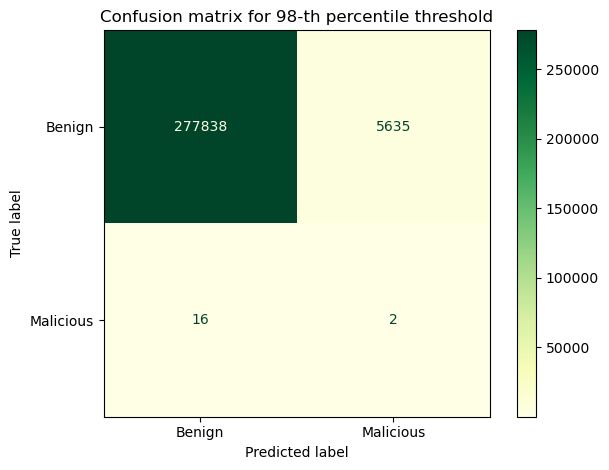

In [13]:
# plot confusion matrix
plt.figure(figsize=(5, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_all,y_pred_all,
    display_labels=["Benign","Malicious"],
    cmap="YlGn"
)

plt.title("Confusion matrix for 98-th percentile threshold")
plt.tight_layout()
plt.show()

## False Negative Analysis

In [14]:
# identify fn and tp cases
fn_mask = ((y_test_all == 1) &(y_pred_all == 0))
tp_mask = ((y_test_all == 1) &(y_pred_all == 1))

# Reconstruct original dataset indices
all_test_indices = []

for fold_data in all_splits["metadata_embedding_semantic_df"]:
    
    all_test_indices.extend(fold_data["X_test"].index)

all_test_indices = np.array(all_test_indices)

# extract original indices for fn and tp
fn_indices = all_test_indices[fn_mask]
tp_indices = all_test_indices[tp_mask]

# extract FN and TP cases from the original dataset
fn_cases = metadata_embedding_semantic_df.loc[fn_indices].copy()
tp_cases = metadata_embedding_semantic_df.loc[tp_indices].copy()

# extract anomaly scores
fn_scores = y_prob_all[fn_mask]
tp_scores = y_prob_all[tp_mask]

# add anomaly scores to the corresponding cases
fn_cases["anomaly_score"] = fn_scores
tp_cases["anomaly_score"] = tp_scores

# 7. Extract all benign cases
benign_cases = metadata_embedding_semantic_df[metadata_embedding_semantic_df["malicious"] == 0].copy()


#### Behavioural features

In [15]:
behavioural_features = [
    "email_count",
    "avg_size",
    "total_size",
    "max_size",
    "avg_receivers",
    "max_receivers",
    "attachment_ratio",
    "unique_receivers",
    "external_receiver_count",
    "external_receiver_ratio",
    "night_time_email_ratio",
    "weekend_email_ratio",
    "max_daily_email",
    "avg_time_between_emails",
    "min_time_between_emails"
]

comparison = pd.DataFrame({
    "FN": fn_cases.mean(numeric_only=True),
    "TP_mean": tp_cases.mean(numeric_only=True),
    "Benign_mean": benign_cases.mean(numeric_only=True)
})

comparison.loc[behavioural_features].T

,email_count,avg_size,total_size,max_size,avg_receivers,max_receivers,attachment_ratio,unique_receivers,external_receiver_count,external_receiver_ratio,night_time_email_ratio,weekend_email_ratio,max_daily_email,avg_time_between_emails,min_time_between_emails
FN,57.437500,628400.256949,3.464258e+07,5.046903e+06,1.834986,4.250000,0.383835,39.062500,15.312500,0.343084,0.046863,0.0000,1.312500,3.162537,0.000434
TP_mean,52.500000,749073.361111,3.733823e+07,5.144924e+06,1.666667,4.000000,0.480159,33.000000,10.000000,0.251906,0.142857,0.0000,3.000000,3.376162,0.000278
Benign_mean,38.782999,477410.974827,1.674028e+07,4.056021e+06,1.935927,4.196858,0.260720,32.711196,13.266304,0.332576,0.030524,0.0154,1.182116,10.103372,3.523214


In [24]:
deviation_features = [
    "email_count_deviation",
    "total_size_deviation",
    "external_receiver_ratio_deviation",
    "night_time_email_ratio_deviation",
    "weekend_email_ratio_deviation",
    "max_daily_email_deviation"
]

comparison = pd.DataFrame({
    "FN": fn_cases.mean(numeric_only=True),
    "TP_mean": tp_cases.mean(numeric_only=True),
    "Benign_mean": benign_cases.mean(numeric_only=True)
})

comparison.loc[deviation_features].T

,email_count_deviation,total_size_deviation,external_receiver_ratio_deviation,night_time_email_ratio_deviation,weekend_email_ratio_deviation,max_daily_email_deviation
FN,3.601562,7.605105e+06,0.020924,-0.012600,0.000000,-0.109375
TP_mean,-5.000000,3.114945e+06,-0.067566,0.098518,0.000000,1.562500
Benign_mean,-0.406248,-1.922103e+05,0.003191,-0.000189,-0.001177,-0.001419


#### Organisational features

In [27]:
ldap_features = [
    col
    for col in fn_cases.columns
    if (
        "role_" in col
        or "team_" in col
        or "department_" in col
        or "functional_unit_" in col
        or "business_unit_" in col
    )
]

# identify LDAP features present in FN cases
fn_ldap = fn_cases[ldap_features]
selected_ldap = fn_ldap.columns[(fn_ldap != 0).any(axis=0)]

ldap_comparison = pd.DataFrame({
    "FN": fn_cases[selected_ldap].mean(),
    "TP": tp_cases[selected_ldap].mean(),
    "Benign": benign_cases[selected_ldap].mean()
})

ldap_comparison.T

,role_ElectricalEngineer,role_Salesman,role_nan,business_unit_1.0,business_unit_nan,functional_unit_2 - ResearchAndEngineering_Commercial,functional_unit_3 - ResearchAndEngineering_Government_Domestic,functional_unit_8 - SalesAndMarketing_Commercial,functional_unit_9 - SalesAndMarketing_Government,functional_unit_nan,department_2 - Sales,department_4 - Engineering,department_nan,team_13 - ElectricalEngineering,team_24 - SystemsEngineering,team_3 - RegionalSales,team_4 - RegionalSales,team_nan
FN,0.625000,0.312500,0.062500,0.937500,0.062500,0.562500,0.062500,0.062500,0.250000,0.062500,0.31250,0.625000,0.062500,0.562500,0.062500,0.062500,0.250000,0.062500
TP,0.500000,0.500000,0.000000,1.000000,0.000000,0.500000,0.000000,0.500000,0.000000,0.000000,0.50000,0.500000,0.000000,0.500000,0.000000,0.500000,0.000000,0.000000
Benign,0.101043,0.089811,0.002667,0.997333,0.002667,0.178677,0.177841,0.096478,0.097396,0.003189,0.09487,0.327022,0.008216,0.012276,0.015102,0.015469,0.015335,0.042942


#### Semantic features

In [17]:
semantic_features = [
        "semantic_deviation",
        "mean_distance_to_history",
        "max_distance_to_history",
        "std_distance_to_history"
]

comparison.loc[semantic_features].T

,semantic_deviation,mean_distance_to_history,max_distance_to_history,std_distance_to_history
FN,0.578616,0.801168,1.016773,0.118898
TP_mean,0.686842,0.866451,1.051523,0.102556
Benign_mean,0.617749,0.814589,1.010430,0.112858


#### Anomaly score 

In [18]:
fn_score_summary = pd.DataFrame({
    "Statistic": [
        "98th-percentile threshold",
        "Mean anomaly score",
        "Median anomaly score",
        "Minimum anomaly score",
        "Maximum anomaly score",
        "Threshold gap for closest FN"
    ],

    "FN": [
        threshold,
        np.mean(fn_scores),
        np.median(fn_scores),
        np.min(fn_scores),
        np.max(fn_scores),
        threshold - np.max(fn_scores)
    ],

    "TP": [
        np.nan,
        np.mean(tp_scores),
        np.median(tp_scores),
        np.min(tp_scores),
        np.max(tp_scores),
        np.nan
    ],

    "Benign": [
        np.nan,
        np.mean(y_prob_all[y_test_all == 0]),
        np.median(y_prob_all[y_test_all == 0]),
        np.min(y_prob_all[y_test_all == 0]),
        np.max(y_prob_all[y_test_all == 0]),
        np.nan
    ]
})

fn_score_summary

,Statistic,FN,TP,Benign
0,98th-percentile threshold,0.426193,NaN,NaN
1,Mean anomaly score,0.412022,0.427221,0.411951
2,Median anomaly score,0.411493,0.427221,0.411716
3,Minimum anomaly score,0.402179,0.427203,0.384274
4,Maximum anomaly score,0.425207,0.427238,0.457692
5,Threshold gap for closest FN,0.000987,NaN,NaN
